In [ ]:
!pip install keras-self-attention
!pip install optuna

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18895 sha256=796bf04074cdc16845d867cb4e8760168c4045b349a60a3dd636ae765b46cf3e
  Stored in directory: /root/.cache/pip/wheels/9a/9d/6e/09a0f61c2edeaea9f96fecdc67f31455c363bb44a4ddabe746
Successfully built keras-self-attention
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 30.8 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, regularizers, Input, Model, optimizers
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import seaborn as sns
import tensorflow as tf
import optuna

### Set random seeds

In [ ]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.keras.utils.set_random_seed(42)

### Historical wheat futures prices data (1999-2025) from Investing.com

In [ ]:
df = pd.read_csv('US Wheat Futures Historical Data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date', drop=True)
df.sort_index(inplace=True)
df['Price'] = df['Price'].str.replace(',', '').astype('float64')
df_price = df['Price']
df_price

,Price
Date,
1999-08-01,264.75
1999-08-02,282.75
1999-08-03,272.00
1999-08-04,276.50
1999-08-05,278.50
...,...
2025-12-04,540.25
2025-12-05,535.75
2025-12-08,534.75


### Macroeconomics data (1999-08 ~ 2024-12) from FRED

In [ ]:
df_features = pd.read_csv('FRED.csv')
df_features = df_features.dropna(how='all', axis=1)
features_missing = []

for col in df_features.columns:
    if col == "Month":
        continue
    s = df_features[col].isna() | (df_features[col] == "")
    if not s.any():
        continue

    features_missing.append(col)

df_features['Month'] = pd.to_datetime(df_features['Month'])
df_features = df_features.set_index('Month').sort_index()
df_selected = df_features.drop(columns=features_missing)
features = [
    "RPI", "W875RX1", "CMRMTSPLx",
    "IPFPNSS", "USWTRADE",
    "USTRADE", "BUSLOANS", "CONSPI", "S&P 500",
    "S&P PE ratio", "FEDFUNDS", "TB3MS", "TB6MS", "GS1", "GS5",
    "GS10", "AAA", "BAA", "TB3SMFFM", "TB6SMFFM", "T1YFFM",
    "T5YFFM", "T10YFFM", "AAAFFM", "BAAFFM",
    "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx", "OILPRICEx",
    "PPICMM", "UMCSENTx"
]

df_features = df_features[features]
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,PPICMM,UMCSENTx
Month,,,,,,,,,,,,,,,,,,,,,
1999-08-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-01,3842.561807,3321.054004,434465.878601,76.647955,4924.282787,14716.772541,488.191875,0.131016,243.143463,15.946036,...,0.765184,1.459590,2.446885,2.685952,245.311656,2.078418,1.164706,14.435947,84.190164,86.923054
1999-10-01,3848.215369,3325.640164,435231.819302,76.748350,4928.615542,14733.366053,489.693146,0.130962,245.341881,15.946036,...,0.765051,1.461043,2.447975,2.683581,245.028555,2.077490,1.165345,14.455260,84.245808,86.983582
1999-11-01,7120.796970,5617.389362,435231.819302,76.878239,4932.944898,14749.936735,491.519876,0.129403,247.494265,16.060393,...,0.765347,1.462857,2.449469,2.681144,244.744752,2.076632,1.165982,14.471963,84.305102,87.031845
1999-12-01,4191.127291,4126.544304,435231.819302,76.987908,4937.331976,14766.598778,493.105573,0.129341,249.823198,16.060393,...,0.765031,1.463829,2.450041,2.678849,244.459423,2.075703,1.166596,14.493344,84.370265,87.091691
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,9492.169116,8090.965184,820836.295036,71.747139,4775.909784,11914.240915,842.746761,0.135582,925.983875,19.389145,...,1.003685,2.001372,3.001321,2.088519,193.962642,1.870707,1.197099,32.890892,126.494198,85.244708
2024-09-01,9519.405260,8109.921193,822489.552603,71.782490,4777.690102,11918.954061,845.149648,0.135488,931.760812,19.422432,...,1.000558,1.998249,2.997855,2.086957,193.902111,1.869976,1.197313,32.946462,126.678704,85.217350
2024-10-01,9532.882349,8120.457541,821633.252409,71.819452,4779.453739,11923.708238,847.602589,0.135506,937.704411,19.422432,...,0.997503,1.995146,2.994423,2.085386,193.837538,1.869281,1.197512,32.993729,126.864238,85.193543


### Shift the dates of macroeconomics data by 1 month into the future, since each month's macroeconomics data is usually released in the next month and remains unknown in the current month. Then use forward-fill to transform monthly data into daily series

In [ ]:
df_features = df_features.shift(periods=1, freq='infer').dropna()   # shift index by one month forward

# 2. Compute new daily date range covering the full span
start = df_features.index.min().replace(day=1)
end = (df_features.index.max() + pd.offsets.MonthEnd(0))
all_days = pd.date_range(start, end, freq='D')

# 3. Reindex to daily frequency and forward-fill missing values
df_features = df_features.reindex(all_days).ffill()
df_features.to_csv('features.csv')
df_features

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,PPICMM,UMCSENTx
1999-09-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-02,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-03,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-04,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
1999-09-05,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,0.764969,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,0.993692,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451


### Use intersections between wheat futures data and macroeconomics data to build the dataset for this forecasting task  (inner join the two datasets on dates)

In [ ]:
df_all = df_features.join(df_price, how='inner')
df_all

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,PPICMM,UMCSENTx,Price
1999-09-01,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,266.75
1999-09-02,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,270.75
1999-09-03,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,272.75
1999-09-07,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,277.00
1999-09-08,3836.968313,3321.054004,434465.878601,76.546257,4919.936345,14699.952772,485.720063,0.131076,240.916879,15.946036,...,1.457803,2.445585,2.688368,245.582877,2.079388,1.164031,14.421934,84.141068,86.870270,269.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,535.50
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,545.25
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,562.50
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,566.50


### Only use data starting in 2008 for training and testing, as financial markets generally behave differently before and after the 2008 financial crisis, leading to a structural break (this is a common practice in financial forecasting). Stale data may hurt model performances

In [ ]:
df_all = df_all['2008-01-01':]
df_all

,RPI,W875RX1,CMRMTSPLx,IPFPNSS,USWTRADE,USTRADE,BUSLOANS,CONSPI,S&P 500,S&P PE ratio,...,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,OILPRICEx,PPICMM,UMCSENTx,Price
2008-01-01,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,929.50
2008-01-02,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,915.00
2008-01-03,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,945.00
2008-01-04,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,931.50
2008-01-07,5206.744804,4559.022147,515616.765189,63.553108,4477.462862,10783.078876,460.495911,0.131964,407.244378,17.712774,...,1.663748,2.639642,2.470920,223.330371,2.013369,1.195918,19.162763,96.012947,88.098614,903.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-27,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,535.50
2025-01-28,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,545.25
2025-01-29,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,562.50
2025-01-30,9559.097642,8140.815297,823452.726454,71.888719,4783.035777,11933.070670,852.486774,0.135546,950.152996,19.458187,...,1.990872,2.989292,2.082316,193.731252,1.867814,1.197990,33.089750,127.267574,85.149451,566.50


### There are 33 features in total (including wheat futures price itself), and the lookback period is 30 days before the target date. So each X sample has a rectangular shape (30 * 33). We are doing one-step-ahead forecast, so each y label is just target day's wheat futures price

In [ ]:
lookback = 30

data = df_all.values
X, y = [], []
for i in range(len(data) - lookback):
    seq_x = data[i : i + lookback, :]          # past 30 days of all features + price
    target = data[i + lookback, -1]
    X.append(seq_x)
    y.append(target)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4458, 30, 33)
y shape: (4458,)


In [ ]:
df_all['Price']

,Price
2008-01-01,929.50
2008-01-02,915.00
2008-01-03,945.00
2008-01-04,931.50
2008-01-07,903.00
...,...
2025-01-27,535.50
2025-01-28,545.25
2025-01-29,562.50
2025-01-30,566.50


### Evolution of the wheat futures price since 2008. It reached its peak during 2022-2023 and gradually dropped to the historical average price after that. Wheat futures probably has mean-reversion property

<Axes: >

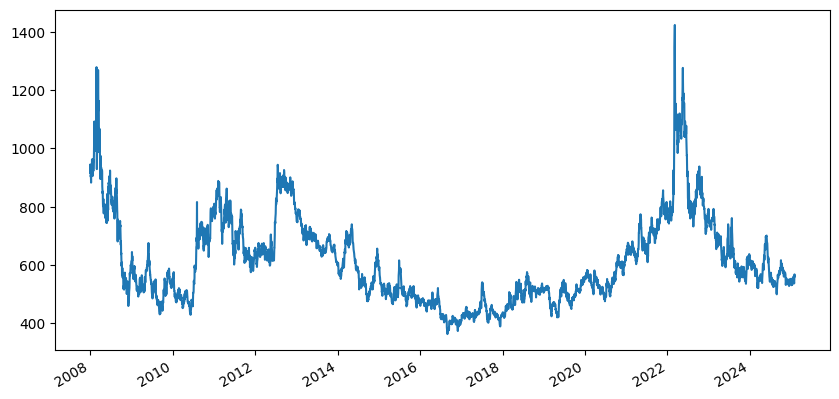

In [ ]:
df_all['Price'].plot(figsize=(10, 5))

### This function builds a GRU model that has: one GRU/BiGRU layer (returns hidden states for all time steps) as encoder, followed by an optional self-attention mechanism, then another GRU layer as the decoder (only returns the hidden state for the last time step), and finally a dense head for regression output.

In [ ]:
def build_gru_with_self_attention(
    seq_length: int = 30,
    feature_dim: int = 33,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,
    # Encoder params
    encoder_units: int = 64,
    encoder_bidirectional: bool = False,
    # Attention params
    use_attention: bool = False,
    attention_activation: str = 'sigmoid',
    # Decoder params
    decoder_units: int = 128,
    # Output head params
    output_activation: str = 'linear',
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))

    # Encoder
    def make_encoder_layer():
        return layers.GRU(
            units=encoder_units,
            dropout=dropout,
            kernel_regularizer=regularizers.l2(kernel_reg),
            return_sequences=True
        )

    if encoder_bidirectional:
        x = layers.Bidirectional(make_encoder_layer())(inputs)
    else:
        x = make_encoder_layer()(inputs)

    # Optional Self-Attention
    if use_attention:
        x = SeqSelfAttention(
            attention_activation=attention_activation
        )(x)

    # Decoder
    def make_decoder_layer():
        return layers.GRU(
            units=decoder_units,
            dropout=dropout,
            kernel_regularizer=regularizers.l2(kernel_reg)
        )

    x = make_decoder_layer()(x)

    # Output head
    outputs = layers.Dense(
        units=1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg)
    )(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model

### 80/20 train test split (no shuffling)

In [ ]:
test_size = int(X.shape[0]*0.2)

X_train = X[: -test_size]
y_train = y[: -test_size]

X_test = X[-test_size : ]
y_test = y[-test_size : ]

print("Training set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (3567, 30, 33) (3567,)
Test set: (891, 30, 33) (891,)


### cv_gru function trains several newly-initialized GRU models with the same set of hyperparameter values using expanding window cross-validation, early stopping and a learning rate schedule. It returns the average validation set loss (average of the MSEs) in the cross-validation process. The average loss is used to assess the performance of the current hyperparameter values set

### Feature values and target values are both standardized in each fold

In [ ]:
def cv_gru(
    X_train: np.ndarray,
    y_train: np.ndarray,
    model_builder,
    encoder_bidirectional: bool = False,
    use_attention: bool = False,
    weight_decay: float = 0.02,
    encoder_units: int = 64,
    decoder_units: int = 32,
    dropout: float = 0.2,
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3
) -> object:
    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    val_losses = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        ns_tr, ns_val = X_tr.shape[0], X_val.shape[0]
        X_tr_flat = X_tr.reshape((ns_tr, lookback * n_features))
        X_val_flat = X_val.reshape((ns_val, lookback * n_features))

        scaler = StandardScaler()
        X_tr_flat_s = scaler.fit_transform(X_tr_flat)
        X_val_flat_s = scaler.transform(X_val_flat)

        X_tr_s = X_tr_flat_s.reshape((ns_tr, lookback, n_features))
        X_val_s = X_val_flat_s.reshape((ns_val, lookback, n_features))

        y_scaler = StandardScaler()
        y_tr_scaled = y_scaler.fit_transform(y_tr.reshape(-1, 1))
        y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1))

        model = model_builder(encoder_bidirectional=encoder_bidirectional, use_attention=use_attention, kernel_reg=weight_decay, dropout=dropout, encoder_units=encoder_units, decoder_units=decoder_units)
        optimizer = optimizers.Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss='mean_squared_error')

        early_stop = EarlyStopping(monitor='val_loss',
                                   patience=early_stop_patience,
                                   verbose=0,
                                   restore_best_weights=True)

        reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                      factor=0.5,
                                      patience=5,
                                      min_lr=1e-6,
                                      verbose=0)

        history = model.fit(
            X_tr_s, y_tr_scaled,
            validation_data=(X_val_s, y_val_scaled),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=False,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        best_val_loss = min(history.history['val_loss'])
        val_losses.append(best_val_loss)

    return np.mean(val_losses)

### Optuna tries to find a set of hyperparameter values that will minimize the average validation set loss in the CV

### Hyperparameters are: weight decay/kernel regularization rate, number of units in encoder GRU layer, number of units in decoder GRU layer, dropout rate, early-stop patience, number of epochs, batch size and learning rate

In [ ]:
def objective(trial):

    weight_decay = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    encoder_units = trial.suggest_categorical("encoder_units", [32, 64, 128])
    decoder_units = trial.suggest_categorical("decoder_units", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs = trial.suggest_int("epochs", 50, 200)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)

    cv_score = cv_gru(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_gru_with_self_attention,
        encoder_bidirectional=False,
        use_attention=False,
        weight_decay=weight_decay,
        encoder_units=encoder_units,
        decoder_units=decoder_units,
        dropout=dropout,
        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate
    )

    return cv_score


study = optuna.create_study(direction="minimize")

study.optimize(
    objective,
    n_trials=50,
    timeout=None
)

print("Best CV score (val_loss):", study.best_value)
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


[I 2025-12-15 00:17:04,195] A new study created in memory with name: no-name-99a8734d-b8eb-4269-9840-df524cad238e
[I 2025-12-15 00:18:05,816] Trial 0 finished with value: 1.5525113344192505 and parameters: {'weight_decay': 0.0019648988778448897, 'encoder_units': 128, 'decoder_units': 64, 'dropout': 0.2748290334929626, 'early_stop_patience': 11, 'epochs': 158, 'batch_size': 64, 'learning_rate': 0.03485656391021916}. Best is trial 0 with value: 1.5525113344192505.
[I 2025-12-15 00:19:22,540] Trial 1 finished with value: 0.3711719959974289 and parameters: {'weight_decay': 0.0009748677341937703, 'encoder_units': 32, 'decoder_units': 128, 'dropout': 0.11934388576646511, 'early_stop_patience': 10, 'epochs': 185, 'batch_size': 64, 'learning_rate': 2.0273430769881077e-05}. Best is trial 1 with value: 0.3711719959974289.
[I 2025-12-15 00:20:50,598] Trial 2 finished with value: 0.3614697098731995 and parameters: {'weight_decay': 0.0014335621673609508, 'encoder_units': 64, 'decoder_units': 64, 'd

Best CV score (val_loss): 0.1916541039943695
Best hyperparameters:
  weight_decay: 0.015111738694059896
  encoder_units: 64
  decoder_units: 32
  dropout: 0.10946654746357193
  early_stop_patience: 13
  epochs: 116
  batch_size: 32
  learning_rate: 0.0017282126069300488


### plot_best_gru function trains a newly-initialized GRU model with the optimized hyperparameter values (found by Optuna) on the last fold of the expanding window CV (where the training set is largest and the validation set is the smallest), then calculates and plots the trained model's performances on training, validation and testing samples

In [ ]:
def plot_best_gru(
    df_all,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    model_builder,
    encoder_bidirectional: bool = False,
    use_attention: bool = False,
    weight_decay: float = 0.02,
    encoder_units: int = 64,
    decoder_units: int = 32,
    dropout: float = 0.2,
    early_stop_patience: int = 10,
    epochs: int = 100,
    batch_size: int = 64,
    learning_rate: float = 1e-3
) -> object:

    tscv = TimeSeriesSplit(n_splits=5, max_train_size=None)
    lookback, n_features = X_train.shape[1], X_train.shape[2]

    # train / val fit on last CV fold
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        if fold == 4:
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            ns_tr, ns_val = X_tr.shape[0], X_val.shape[0]
            X_tr_flat = X_tr.reshape((ns_tr, lookback * n_features))
            X_val_flat = X_val.reshape((ns_val, lookback * n_features))

            scaler = StandardScaler()
            X_tr_flat_s = scaler.fit_transform(X_tr_flat)
            X_val_flat_s = scaler.transform(X_val_flat)

            X_tr_s = X_tr_flat_s.reshape((ns_tr, lookback, n_features))
            X_val_s = X_val_flat_s.reshape((ns_val, lookback, n_features))

            y_scaler = StandardScaler()
            y_tr_scaled = y_scaler.fit_transform(y_tr.reshape(-1, 1))
            y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1))

            model = model_builder(
                encoder_bidirectional=encoder_bidirectional,
                use_attention=use_attention,
                kernel_reg=weight_decay,
                dropout=dropout,
                encoder_units=encoder_units,
                decoder_units=decoder_units
            )

            optimizer = optimizers.Adam(learning_rate=learning_rate)
            model.compile(optimizer=optimizer, loss='mean_squared_error')

            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=early_stop_patience,
                verbose=0,
                restore_best_weights=True
            )

            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-6,
                verbose=0
            )

            history = model.fit(
                X_tr_s, y_tr_scaled,
                validation_data=(X_val_s, y_val_scaled),
                epochs=epochs,
                batch_size=batch_size,
                shuffle=False,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )

    # --- TRAIN set evaluation + plot ---
    y_tr_pred_scaled = model.predict(X_tr_s, verbose=0)
    y_tr_pred = y_scaler.inverse_transform(y_tr_pred_scaled.reshape(-1, 1))

    train_rmse = np.sqrt(mean_squared_error(y_tr, y_tr_pred))
    train_r2   = r2_score(y_tr, y_tr_pred)
    train_mae  = mean_absolute_error(y_tr, y_tr_pred)

    print("\n=== Train set performance ===")
    print(f"Train RMSE: {train_rmse:.6f}")
    print(f"Train R²  : {train_r2:.6f}")
    print(f"Train MAE : {train_mae:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_tr, label='Actual (train)')
    plt.plot(y_tr_pred, label='Predicted (train)')
    plt.title('Train: Actual vs Predicted')
    plt.legend()
    plt.show()

    # --- VAL set evaluation + plot ---
    y_val_pred_scaled = model.predict(X_val_s, verbose=0)
    y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled.reshape(-1, 1))

    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2   = r2_score(y_val, y_val_pred)
    val_mae  = mean_absolute_error(y_val, y_val_pred)

    print("\n=== Validation set performance ===")
    print(f"Val RMSE: {val_rmse:.6f}")
    print(f"Val R²  : {val_r2:.6f}")
    print(f"Val MAE : {val_mae:.6f}")

    plt.figure(figsize=(10, 4))
    plt.plot(y_val, label='Actual (val)')
    plt.plot(y_val_pred, label='Predicted (val)')
    plt.title('Validation: Actual vs Predicted')
    plt.legend()
    plt.show()

    # --- TEST set scaling + evaluation ---
    scaler_full = StandardScaler()
    X_train_flat = X_train.reshape((X_train.shape[0], lookback * n_features))
    scaler_full.fit(X_train_flat)

    X_test_flat = X_test.reshape((X_test.shape[0], lookback * n_features))
    X_test_scaled_flat = scaler_full.transform(X_test_flat)
    X_test_scaled = X_test_scaled_flat.reshape((X_test.shape[0], lookback, n_features))

    y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1))

    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2   = r2_score(y_test, y_test_pred)
    test_mae  = mean_absolute_error(y_test, y_test_pred)

    print("\n=== Test set performance ===")
    print(f"Test RMSE: {test_rmse:.6f}")
    print(f"Test R²  : {test_r2:.6f}")
    print(f"Test MAE : {test_mae:.6f}")

    # --- PLOT test with dates as x axis ---
    # get last len(X_test) dates from df_all.index
    test_len = len(X_test)
    test_dates = df_all.index[-test_len:]

    plt.figure(figsize=(12, 5))
    plt.plot(test_dates, y_test, label='Actual (test)')
    plt.plot(test_dates, y_test_pred, label='Predicted (test)')
    plt.title('Test: Actual vs Predicted')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return model


### Results for the plain GRU model with optimized hyperparameters


=== Train set performance ===
Train RMSE: 45.632260
Train R²  : 0.899351
Train MAE : 34.317738


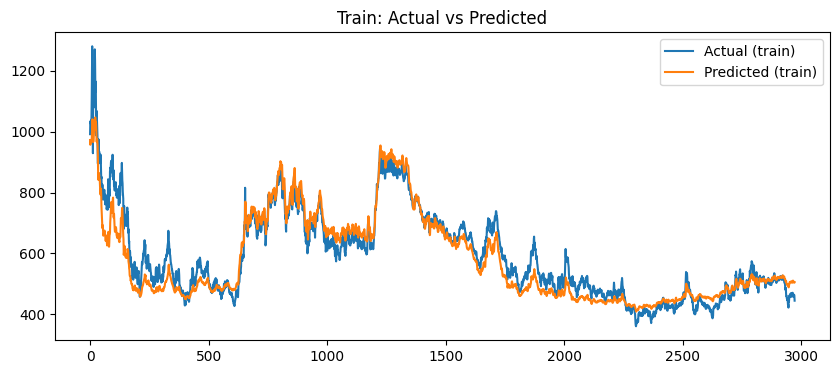


=== Validation set performance ===
Val RMSE: 38.425149
Val R²  : 0.721680
Val MAE : 30.780043


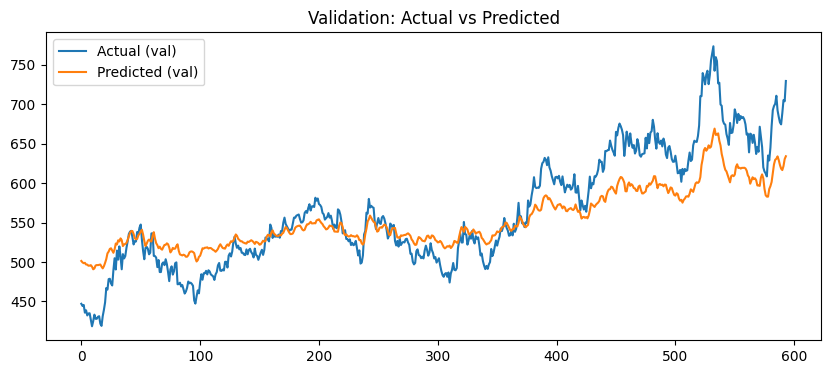


=== Test set performance ===
Test RMSE: 71.664095
Test R²  : 0.804768
Test MAE : 50.942726


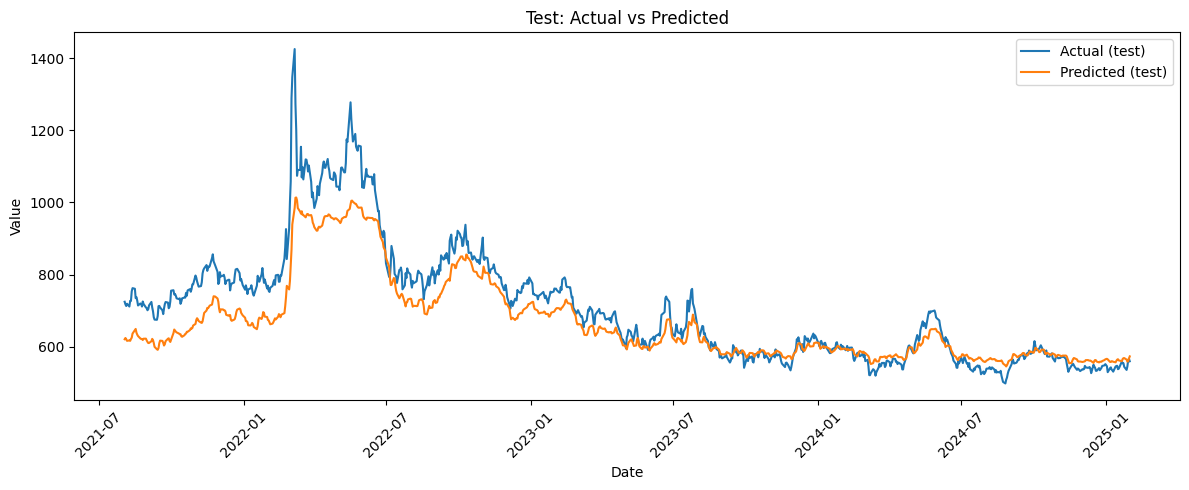

<Functional name=functional_251, built=True>

In [ ]:
plot_best_gru(df_all, X_train,y_train,X_test,y_test,build_gru_with_self_attention, encoder_bidirectional=False, use_attention=False, weight_decay=0.015111738694059896,
              encoder_units=64, decoder_units=32, dropout=0.10946654746357193, early_stop_patience=13, epochs=116, batch_size=32, learning_rate=0.0017282126069300488)

### Now use Optuna to find the best hyperparameter values for the Bi-GRU model

In [ ]:
def objective(trial):

    weight_decay = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    encoder_units = trial.suggest_categorical("encoder_units", [32, 64, 128])
    decoder_units = trial.suggest_categorical("decoder_units", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs = trial.suggest_int("epochs", 50, 200)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)

    cv_score = cv_gru(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_gru_with_self_attention,
        encoder_bidirectional=True,
        use_attention=False,
        weight_decay=weight_decay,
        encoder_units=encoder_units,
        decoder_units=decoder_units,
        dropout=dropout,
        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate
    )

    return cv_score


study = optuna.create_study(direction="minimize")

study.optimize(
    objective,
    n_trials=50,
    timeout=None
)

print("Best CV score (val_loss):", study.best_value)
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2025-12-15 02:07:11,493] A new study created in memory with name: no-name-0e3946de-f0cf-4b23-90cb-beaf24a210d2
[I 2025-12-15 02:09:17,185] Trial 0 finished with value: 0.7659970551729203 and parameters: {'weight_decay': 0.0009462226634349263, 'encoder_units': 128, 'decoder_units': 128, 'dropout': 0.18367774420278415, 'early_stop_patience': 10, 'epochs': 185, 'batch_size': 64, 'learning_rate': 3.203124545270365e-05}. Best is trial 0 with value: 0.7659970551729203.
[I 2025-12-15 02:11:09,621] Trial 1 finished with value: 0.5146754860877991 and parameters: {'weight_decay': 0.005420556476795943, 'encoder_units': 128, 'decoder_units': 32, 'dropout': 0.19210767272372842, 'early_stop_patience': 10, 'epochs': 111, 'batch_size': 64, 'learning_rate': 0.001880913136206856}. Best is trial 1 with value: 0.5146754860877991.
[I 2025-12-15 02:13:12,951] Trial 2 finished with value: 0.3061158865690231 and parameters: {'weight_decay': 0.001640924415686678, 'encoder_units': 128, 'decoder_units': 64, '

Best CV score (val_loss): 0.1932332456111908
Best hyperparameters:
  weight_decay: 0.0005750376228266232
  encoder_units: 64
  decoder_units: 128
  dropout: 0.14922643816156658
  early_stop_patience: 11
  epochs: 200
  batch_size: 64
  learning_rate: 0.0020927209481461186


### Results for the Bi-GRU model with optimized hyperparameters


=== Train set performance ===
Train RMSE: 67.776221
Train R²  : 0.777965
Train MAE : 56.216022


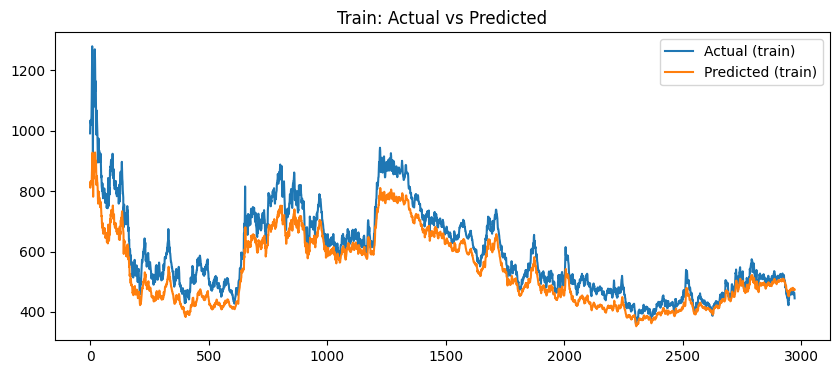


=== Validation set performance ===
Val RMSE: 37.623706
Val R²  : 0.733169
Val MAE : 28.338473


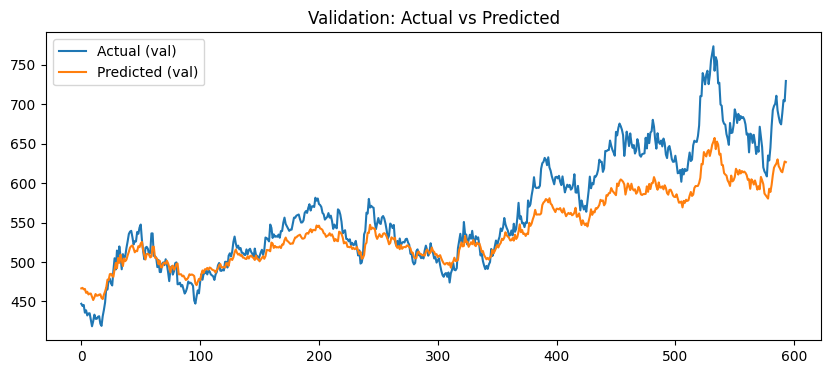


=== Test set performance ===
Test RMSE: 97.485965
Test R²  : 0.638731
Test MAE : 66.226402


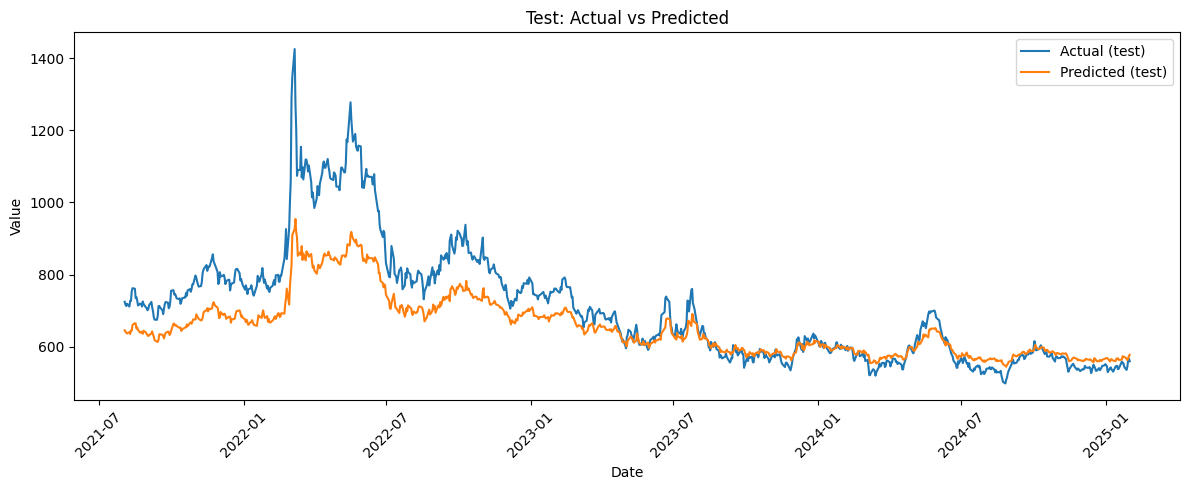

<Functional name=functional_503, built=True>

In [ ]:
plot_best_gru(df_all, X_train,y_train,X_test,y_test,build_gru_with_self_attention, encoder_bidirectional=True, use_attention=False, weight_decay=0.0005750376228266232,
              encoder_units=64, decoder_units=128, dropout=0.14922643816156658, early_stop_patience=11, epochs=200, batch_size=64, learning_rate=0.0020927209481461186)

### Find best hyperparameter values for GRU with attention

In [ ]:
def objective(trial):

    weight_decay = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    encoder_units = trial.suggest_categorical("encoder_units", [32, 64, 128])
    decoder_units = trial.suggest_categorical("decoder_units", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs = trial.suggest_int("epochs", 50, 200)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)

    cv_score = cv_gru(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_gru_with_self_attention,
        encoder_bidirectional=False,
        use_attention=True,
        weight_decay=weight_decay,
        encoder_units=encoder_units,
        decoder_units=decoder_units,
        dropout=dropout,
        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate
    )

    return cv_score


study = optuna.create_study(direction="minimize")

study.optimize(
    objective,
    n_trials=50,
    timeout=None
)

print("Best CV score (val_loss):", study.best_value)
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2025-12-15 03:43:46,221] A new study created in memory with name: no-name-c2285869-65ad-48a5-8f71-496172d467b1
[I 2025-12-15 03:45:07,711] Trial 0 finished with value: 0.5167488217353821 and parameters: {'weight_decay': 0.0011403142671591268, 'encoder_units': 32, 'decoder_units': 64, 'dropout': 0.29396341455654995, 'early_stop_patience': 13, 'epochs': 117, 'batch_size': 32, 'learning_rate': 0.0003629913759701647}. Best is trial 0 with value: 0.5167488217353821.
[I 2025-12-15 03:46:05,939] Trial 1 finished with value: 0.6332683503627777 and parameters: {'weight_decay': 0.0017381073673991105, 'encoder_units': 32, 'decoder_units': 64, 'dropout': 0.13573527570020064, 'early_stop_patience': 11, 'epochs': 114, 'batch_size': 64, 'learning_rate': 0.02634561362393133}. Best is trial 0 with value: 0.5167488217353821.
[I 2025-12-15 03:47:26,361] Trial 2 finished with value: 0.6260410070419311 and parameters: {'weight_decay': 0.0021818539026272946, 'encoder_units': 128, 'decoder_units': 64, 'dr

Best CV score (val_loss): 0.2648689478635788
Best hyperparameters:
  weight_decay: 0.0005060028578796381
  encoder_units: 64
  decoder_units: 64
  dropout: 0.1764413777476783
  early_stop_patience: 12
  epochs: 54
  batch_size: 32
  learning_rate: 7.88793661408569e-05


### GRU with attention (optimized hyperparameters) results


=== Train set performance ===
Train RMSE: 53.327623
Train R²  : 0.862541
Train MAE : 35.374399


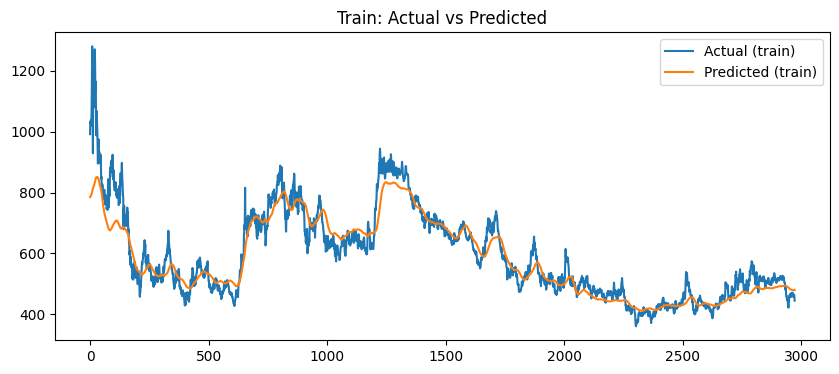


=== Validation set performance ===
Val RMSE: 70.265164
Val R²  : 0.069336
Val MAE : 53.579948


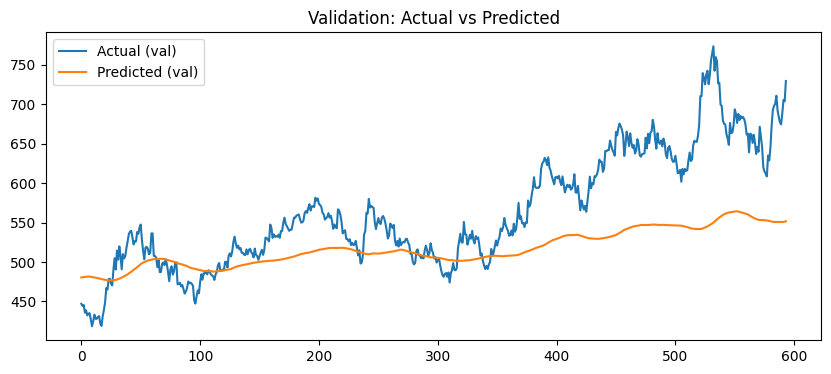


=== Test set performance ===
Test RMSE: 176.094857
Test R²  : -0.178800
Test MAE : 131.602658


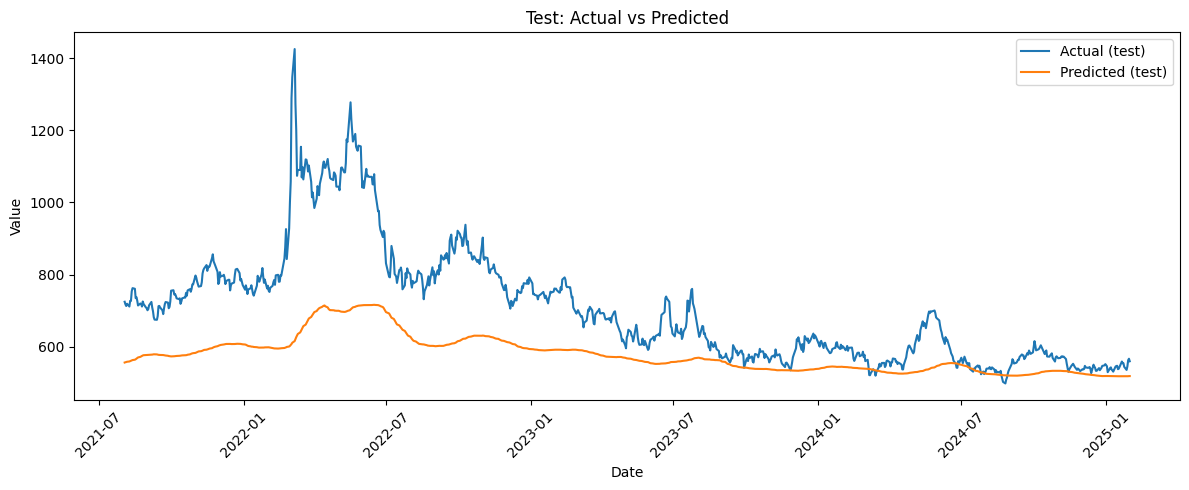

<Functional name=functional_754, built=True>

In [ ]:
plot_best_gru(df_all, X_train,y_train,X_test,y_test,build_gru_with_self_attention, encoder_bidirectional=False, use_attention=True, weight_decay=0.0005060028578796381,
              encoder_units=64, decoder_units=64, dropout=0.1764413777476783, early_stop_patience=12, epochs=54, batch_size=32, learning_rate=7.88793661408569e-05)

### Find best hyperparameter values for Bi-GRU with attention

In [ ]:
def objective(trial):

    weight_decay = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    encoder_units = trial.suggest_categorical("encoder_units", [32, 64, 128])
    decoder_units = trial.suggest_categorical("decoder_units", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs = trial.suggest_int("epochs", 50, 200)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)

    cv_score = cv_gru(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_gru_with_self_attention,
        encoder_bidirectional=True,
        use_attention=True,
        weight_decay=weight_decay,
        encoder_units=encoder_units,
        decoder_units=decoder_units,
        dropout=dropout,
        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate
    )

    return cv_score


study = optuna.create_study(direction="minimize")

study.optimize(
    objective,
    n_trials=50,
    timeout=None
)

print("Best CV score (val_loss):", study.best_value)
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2025-12-15 05:01:24,055] A new study created in memory with name: no-name-977e214b-da99-4b4a-8780-a12d93d49548
[I 2025-12-15 05:03:44,491] Trial 0 finished with value: 0.46627227663993837 and parameters: {'weight_decay': 0.01752063595472657, 'encoder_units': 64, 'decoder_units': 128, 'dropout': 0.2705778444355558, 'early_stop_patience': 10, 'epochs': 139, 'batch_size': 32, 'learning_rate': 0.0018597695898782164}. Best is trial 0 with value: 0.46627227663993837.
[I 2025-12-15 05:06:03,510] Trial 1 finished with value: 0.7458792448043823 and parameters: {'weight_decay': 0.005226148723278554, 'encoder_units': 64, 'decoder_units': 32, 'dropout': 0.18039548441785713, 'early_stop_patience': 10, 'epochs': 103, 'batch_size': 64, 'learning_rate': 0.0006416632202206768}. Best is trial 0 with value: 0.46627227663993837.
[I 2025-12-15 05:07:49,793] Trial 2 finished with value: 0.31084716469049456 and parameters: {'weight_decay': 0.0009384798959731426, 'encoder_units': 64, 'decoder_units': 32, '

Best CV score (val_loss): 0.23549885153770447
Best hyperparameters:
  weight_decay: 0.0006573136016128822
  encoder_units: 64
  decoder_units: 128
  dropout: 0.11487945453642595
  early_stop_patience: 11
  epochs: 132
  batch_size: 32
  learning_rate: 0.0007065154841413128


### Results of Bi-GRU with attention


=== Train set performance ===
Train RMSE: 70.711216
Train R²  : 0.758318
Train MAE : 49.899006


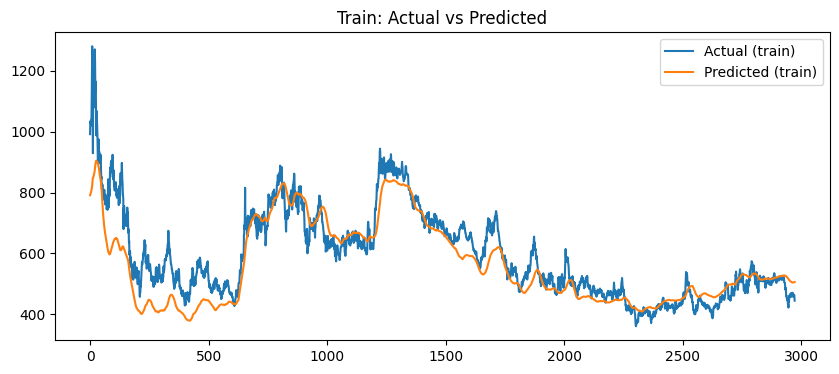


=== Validation set performance ===
Val RMSE: 42.569263
Val R²  : 0.658410
Val MAE : 32.844469


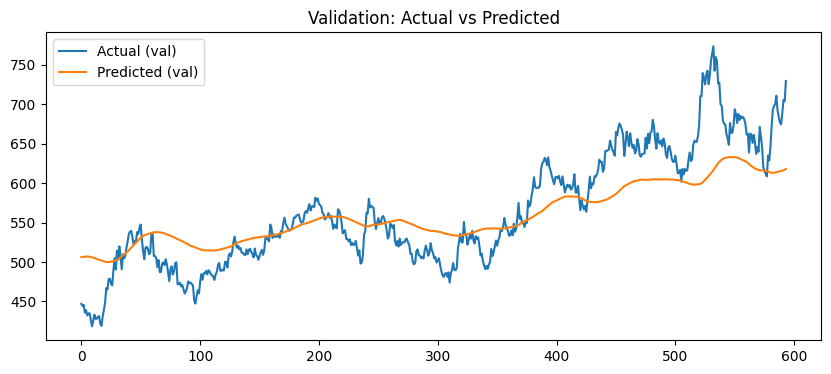


=== Test set performance ===
Test RMSE: 107.947541
Test R²  : 0.557032
Test MAE : 74.332437


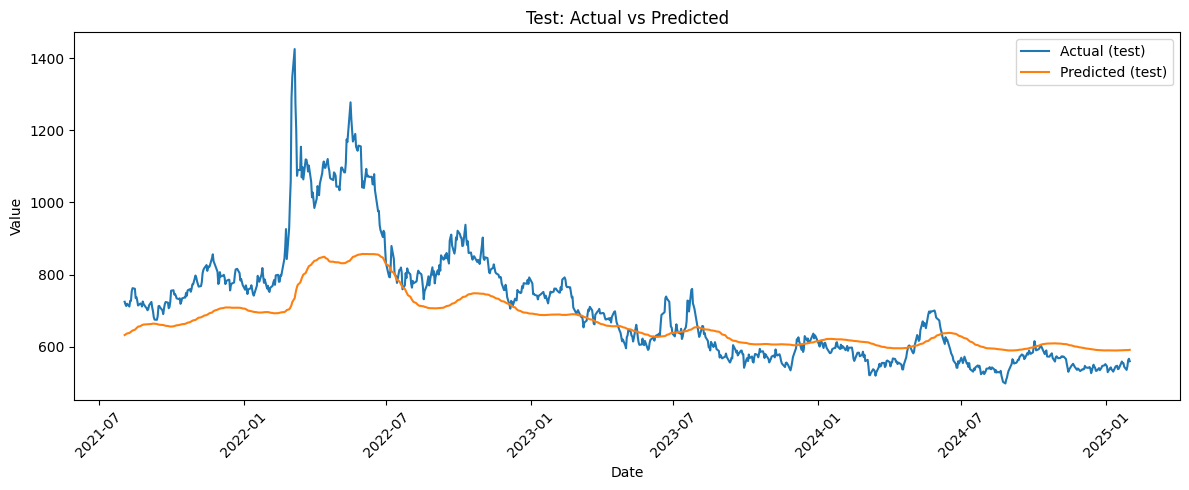

<Functional name=functional_1008, built=True>

In [ ]:
plot_best_gru(df_all, X_train,y_train,X_test,y_test,build_gru_with_self_attention, encoder_bidirectional=True, use_attention=True, weight_decay=0.0006573136016128822,
              encoder_units=64, decoder_units=128, dropout=0.11487945453642595, early_stop_patience=11, epochs=132, batch_size=32, learning_rate=0.0007065154841413128)

### Experiment with adding a residual/skip connection to GRU with attention

In [ ]:
def build_gru_with_self_attention_skip(
    seq_length: int = 30,
    feature_dim: int = 33,
    dropout: float = 0.2,
    kernel_reg: float = 0.02,
    # Encoder params
    encoder_units: int = 64,
    encoder_bidirectional: bool = False,
    # Attention params
    use_attention: bool = False,
    attention_activation: str = "sigmoid",
    # Decoder params
    decoder_units: int = 128,
    # Output head params
    output_activation: str = "linear",
) -> Model:

    inputs = Input(shape=(seq_length, feature_dim))

    # Encoder
    def make_encoder_layer():
        return layers.GRU(
            units=encoder_units,
            dropout=dropout,
            kernel_regularizer=regularizers.l2(kernel_reg),
            return_sequences=True,
        )

    if encoder_bidirectional:
        x = layers.Bidirectional(make_encoder_layer())(inputs)
    else:
        x = make_encoder_layer()(inputs)

    # Optional Self-Attention + Skip Connection
    if use_attention:
        # Keep a residual copy
        residual = x

        # Self-attention layer
        attn_out = SeqSelfAttention(
            attention_activation=attention_activation
        )(x)

        # Add skip connection
        x = layers.Add()([residual, attn_out])

    # Decoder
    def make_decoder_layer():
        return layers.GRU(
            units=decoder_units,
            dropout=dropout,
            kernel_regularizer=regularizers.l2(kernel_reg),
        )

    x = make_decoder_layer()(x)

    # Output head
    outputs = layers.Dense(
        units=1,
        activation=output_activation,
        kernel_regularizer=regularizers.l2(kernel_reg),
    )(x)

    model = Model(inputs=inputs, outputs=outputs)

    return model


### Find best hyperparameters for GRU with attention and skip connection

In [ ]:
def objective(trial):

    weight_decay = trial.suggest_float("weight_decay", 5e-4, 2e-2, log=True)
    encoder_units = trial.suggest_categorical("encoder_units", [32, 64, 128])
    decoder_units = trial.suggest_categorical("decoder_units", [32, 64, 128])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    early_stop_patience = trial.suggest_int("early_stop_patience", 10, 15)
    epochs = trial.suggest_int("epochs", 50, 200)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)

    cv_score = cv_gru(
        X_train=X_train,
        y_train=y_train,
        model_builder=build_gru_with_self_attention_skip,
        encoder_bidirectional=False,
        use_attention=True,
        weight_decay=weight_decay,
        encoder_units=encoder_units,
        decoder_units=decoder_units,
        dropout=dropout,
        early_stop_patience=early_stop_patience,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate
    )

    return cv_score


study = optuna.create_study(direction="minimize")

study.optimize(
    objective,
    n_trials=50,
    timeout=None
)

print("Best CV score (val_loss):", study.best_value)
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2025-12-15 17:49:18,266] A new study created in memory with name: no-name-eadbc568-ff58-4cd2-961a-81f2705343e8
[I 2025-12-15 17:53:30,593] Trial 0 finished with value: 0.8398256361484527 and parameters: {'weight_decay': 0.004375072422964083, 'encoder_units': 128, 'decoder_units': 64, 'dropout': 0.15992043837515352, 'early_stop_patience': 11, 'epochs': 149, 'batch_size': 32, 'learning_rate': 2.9146849474545758e-05}. Best is trial 0 with value: 0.8398256361484527.
[I 2025-12-15 17:55:15,670] Trial 1 finished with value: 0.7045428872108459 and parameters: {'weight_decay': 0.0027730793856319317, 'encoder_units': 32, 'decoder_units': 64, 'dropout': 0.24334276574725097, 'early_stop_patience': 14, 'epochs': 169, 'batch_size': 32, 'learning_rate': 0.034777911473207704}. Best is trial 1 with value: 0.7045428872108459.
[I 2025-12-15 17:56:39,675] Trial 2 finished with value: 0.7243668347597122 and parameters: {'weight_decay': 0.012987086866453855, 'encoder_units': 64, 'decoder_units': 64, 'dr

Best CV score (val_loss): 0.23748220801353453
Best hyperparameters:
  weight_decay: 0.001051319801534546
  encoder_units: 64
  decoder_units: 128
  dropout: 0.24669733635825758
  early_stop_patience: 10
  epochs: 95
  batch_size: 64
  learning_rate: 0.002429926665112449


### Results for GRU with attention and skip connection


=== Train set performance ===
Train RMSE: 136.147217
Train R²  : 0.104048
Train MAE : 106.615839


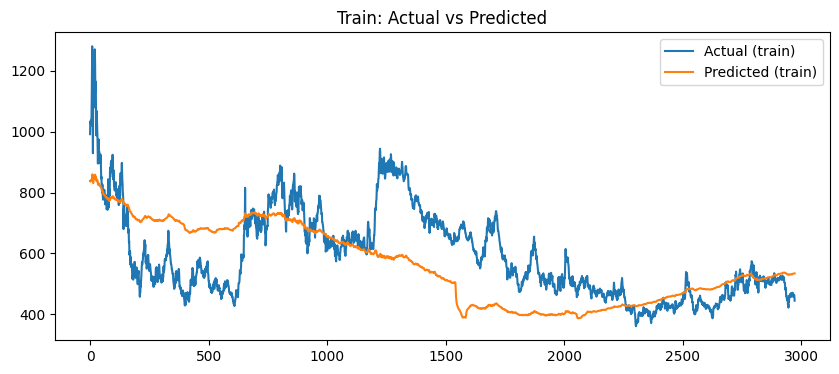


=== Validation set performance ===
Val RMSE: 55.162135
Val R²  : 0.426419
Val MAE : 46.434905


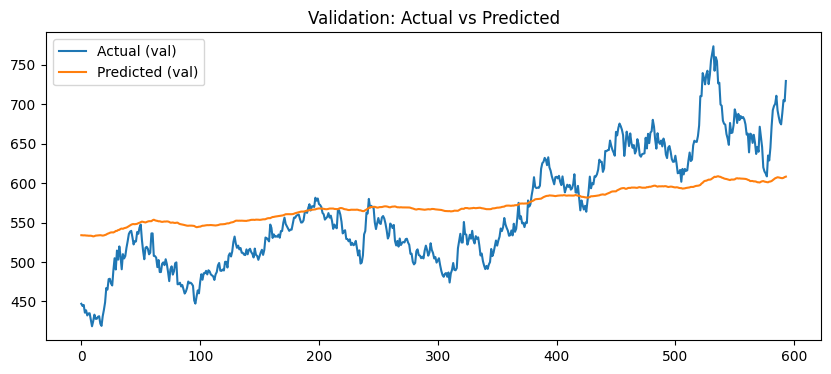


=== Test set performance ===
Test RMSE: 167.914472
Test R²  : -0.071823
Test MAE : 124.733849


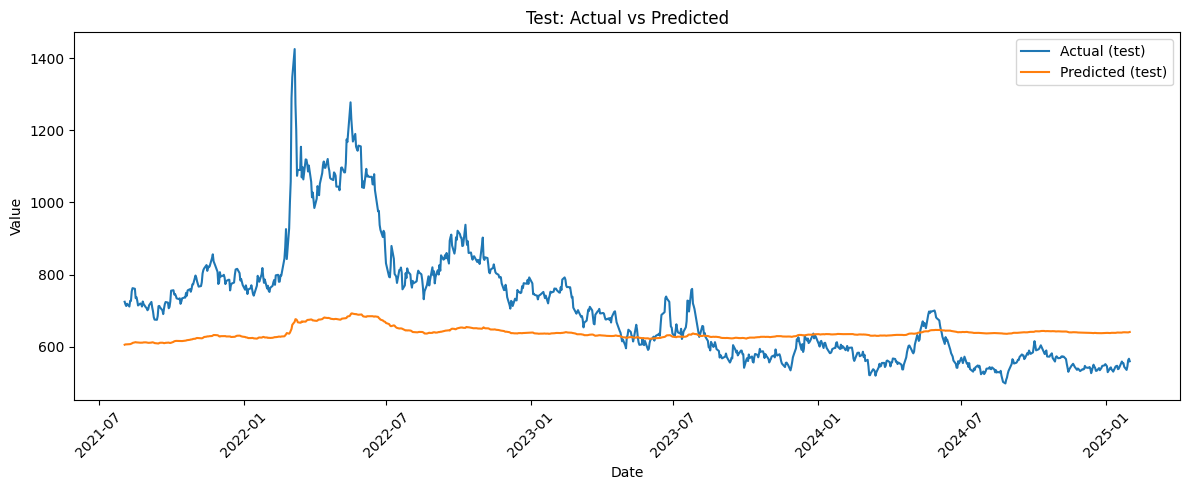

<Functional name=functional_501, built=True>

In [ ]:
plot_best_gru(df_all, X_train,y_train,X_test,y_test,build_gru_with_self_attention_skip, encoder_bidirectional=False, use_attention=True, weight_decay=0.001051319801534546,
              encoder_units=64, decoder_units=128, dropout=0.24669733635825758, early_stop_patience=10, epochs=95, batch_size=64, learning_rate=0.002429926665112449)

### Naive forecast: each day's price prediction is equal to previous day's price

In [ ]:
# --- NAIVE ONE-DAY AHEAD FORECAST ---
# naive forecast for test: next = current
# i.e., y_pred_naive[t] = y_test[t-1], with first one using last train value

# get training end point
last_train_price = y_train[-1]  # last actual train price

# build naive predictions
naive_preds = []
for i in range(len(y_test)):
    if i == 0:
        naive_preds.append(last_train_price)  # first naive uses last train
    else:
        naive_preds.append(y_test[i-1])  # shift by 1

naive_preds = np.array(naive_preds)

naive_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))
naive_mae  = mean_absolute_error(y_test, naive_preds)
naive_r2   = r2_score(y_test, naive_preds)

print("\n=== Naive One-Day-Ahead Forecast Performance ===")
print(f"Naive RMSE: {naive_rmse:.6f}")
print(f"Naive R²  : {naive_r2:.6f}")
print(f"Naive MAE : {naive_mae:.6f}")



=== Naive One-Day-Ahead Forecast Performance ===
Naive RMSE: 20.370589
Naive R²  : 0.984226
Naive MAE : 12.850842


### Plain GRU model without Bi-GRU layer or attention mechanism performs the best in the test set. Attention mechanism didn't improve test set performances for either GRU or Bi-GRU. Adding skip/residual connection didn't improve model performance in this forecasting task. Naive forecast is a very strong baseline that is hard to beat.